In [5]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

X_normal = np.load('../data/anomalyDetection_Normal.npy')   
X_issue  = np.load('../data/anomalyDetection_Issue.npy')    
y_issue  = np.load('../data/anomalyDetection_Labels.npy')   

print(f"Normal data: {X_normal.shape} range [{X_normal.min():.3f}, {X_normal.max():.3f}]")
print(f"Issue data: {X_issue.shape} range [{X_issue.min():.3f},  {X_issue.max():.3f}]")
print(f"Labels: {y_issue.shape} anomalies: {int(y_issue.sum())} / {len(y_issue)}")

Normal data: (1000, 85) range [-1.000, 1.000]
Issue data: (400, 85) range [-1.361,  1.003]
Labels: (400,) anomalies: 25 / 400


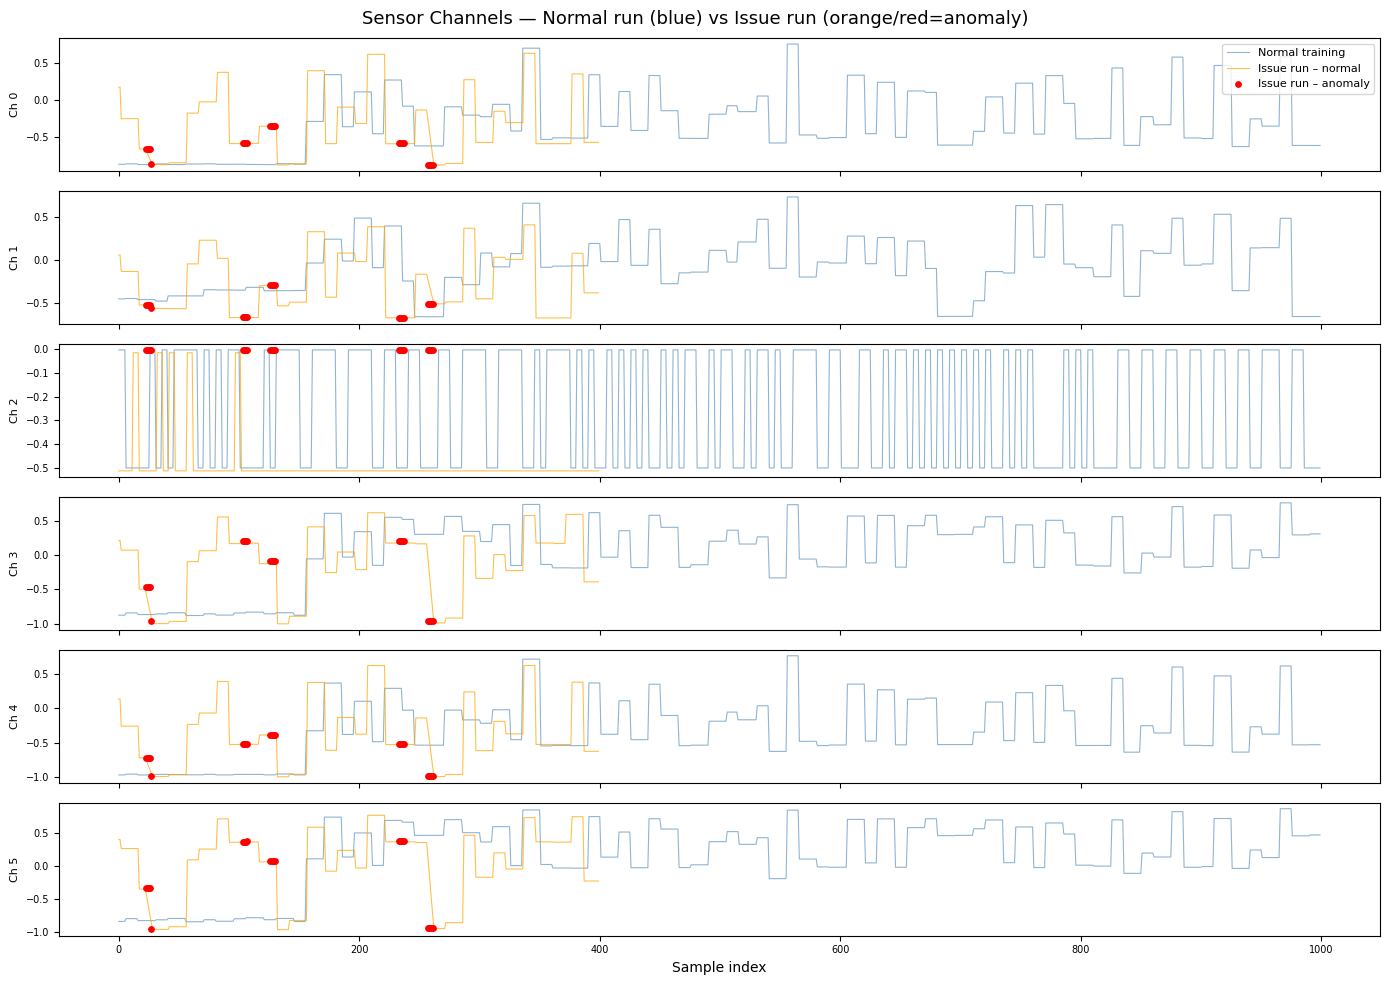

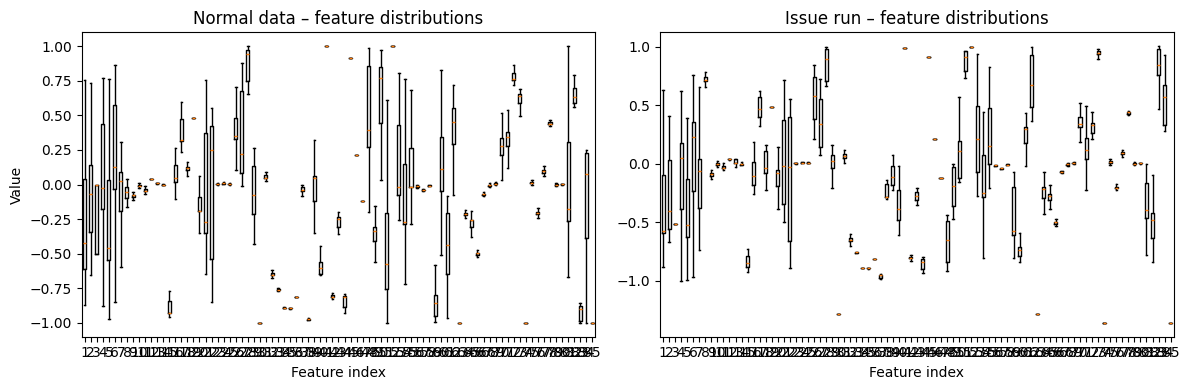

In [13]:
n_channels_to_show = 6
fig, axes = plt.subplots(n_channels_to_show, 1, figsize=(14, 10), sharex=True)
fig.suptitle("Sensor Channels — Normal run (blue) vs Issue run (orange/red=anomaly)", fontsize=13)

anomaly_idx = np.where(y_issue == 1)[0]
normal_idx  = np.where(y_issue == 0)[0]

for ax, ch in zip(axes, range(n_channels_to_show)):
    ax.plot(X_normal[:, ch], color='steelblue', alpha=0.6, lw=0.8, label='Normal training')
    ax.plot(normal_idx,  X_issue[normal_idx,  ch], color='orange', alpha=0.7, lw=0.8, label='Issue run – normal')
    ax.scatter(anomaly_idx, X_issue[anomaly_idx, ch], color='red', s=15, zorder=5, label='Issue run – anomaly')
    ax.set_ylabel(f'Ch {ch}', fontsize=8)
    ax.tick_params(labelsize=7)

axes[0].legend(fontsize=8, loc='upper right')
axes[-1].set_xlabel('Sample index')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].boxplot(X_normal, showfliers=False)
axes[0].set_title('Normal data – feature distributions')
axes[0].set_xlabel('Feature index')
axes[0].set_ylabel('Value')

axes[1].boxplot(X_issue, showfliers=False)
axes[1].set_title('Issue run – feature distributions')
axes[1].set_xlabel('Feature index')

plt.tight_layout()
plt.show()

## Non-Deep-Learning Baselines

  File "c:\Users\dorot\AppData\Local\Programs\Python\Python310\lib\site-packages\joblib\externals\loky\backend\context.py", line 247, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_win32()
  File "c:\Users\dorot\AppData\Local\Programs\Python\Python310\lib\site-packages\joblib\externals\loky\backend\context.py", line 299, in _count_physical_cores_win32
    cpu_info = subprocess.run(
  File "c:\Users\dorot\AppData\Local\Programs\Python\Python310\lib\subprocess.py", line 501, in run
    with Popen(*popenargs, **kwargs) as process:
  File "c:\Users\dorot\AppData\Local\Programs\Python\Python310\lib\subprocess.py", line 966, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "c:\Users\dorot\AppData\Local\Programs\Python\Python310\lib\subprocess.py", line 1435, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,


Isolation Forest                AUC-ROC: 0.5228  |  Best-threshold predictions:
[[ 90 285]
 [  0  25]]
LOF                             AUC-ROC: 0.5547  |  Best-threshold predictions:
[[164 211]
 [  6  19]]


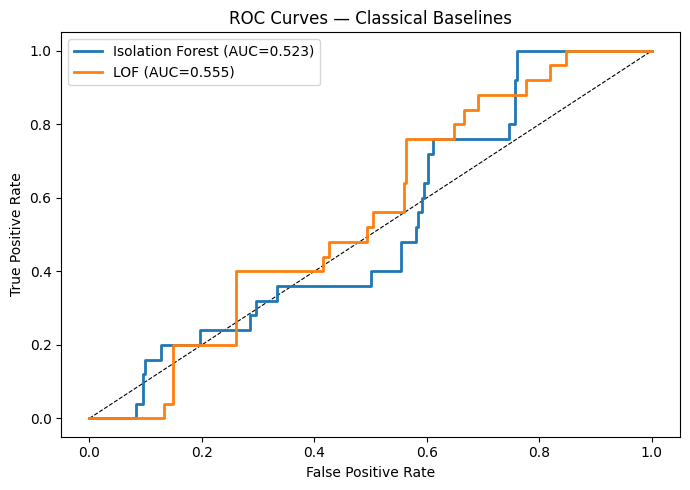

In [ ]:
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor

def evaluate_detector(name, scores, labels):
    """scores: higher = more anomalous."""
    auc = roc_auc_score(labels, scores)
    fpr, tpr, thresholds = roc_curve(labels, scores)
    best_thresh = thresholds[np.argmax(tpr - fpr)]
    preds = (scores >= best_thresh).astype(int)
    cm = confusion_matrix(labels, preds)
    print(f"{name:30s}  AUC-ROC: {auc:.4f}  |  Best-threshold predictions:")
    print(cm)
    return auc, fpr, tpr

iso = IsolationForest(n_estimators=200, contamination='auto', random_state=42)
iso.fit(X_normal)
iso_scores = -iso.decision_function(X_issue)

lof = LocalOutlierFactor(n_neighbors=20, novelty=True, contamination='auto')
lof.fit(X_normal)
lof_scores = -lof.decision_function(X_issue)

fig, ax = plt.subplots(figsize=(7, 5))
ax.set_title('ROC Curves — Classical Baselines')
ax.plot([0, 1], [0, 1], 'k--', lw=0.8)

for name, scores in [('Isolation Forest', iso_scores), ('LOF', lof_scores)]:
    auc, fpr, tpr = evaluate_detector(name, scores, y_issue)
    ax.plot(fpr, tpr, lw=2, label=f'{name} (AUC={auc:.3f})')

ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend()
plt.tight_layout()
plt.show()

## Deep Learning 

In [8]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

tf.random.set_seed(42)

INPUT_DIM  = X_normal.shape[1]   
LATENT_DIM = 16                 

def build_autoencoder(input_dim, latent_dim):
    inputs = keras.Input(shape=(input_dim,), name='encoder_input')
    x = layers.Dense(64, activation='relu')(inputs)
    x = layers.Dense(32, activation='relu')(x)
    encoded = layers.Dense(latent_dim, activation='relu', name='bottleneck')(x)

    x = layers.Dense(32, activation='relu')(encoded)
    x = layers.Dense(64, activation='relu')(x)
    decoded = layers.Dense(input_dim, activation='linear', name='reconstruction')(x)

    autoencoder = keras.Model(inputs, decoded, name='autoencoder')
    return autoencoder

autoencoder = build_autoencoder(INPUT_DIM, LATENT_DIM)
autoencoder.compile(optimizer='adam', loss='mse')
autoencoder.summary()

Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder_input (InputLayer)      │ (None, 85)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         5,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bottleneck (Dense)              │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reconstruction (Dense)          │ (None, 85)             │         5,525 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,293 (63.64 KB)

 Trainable params: 16,293 (63.64 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.2235 - val_loss: 0.1060
Epoch 2/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0584 - val_loss: 0.0469
Epoch 3/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0373 - val_loss: 0.0388
Epoch 4/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0289 - val_loss: 0.0345
Epoch 5/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0239 - val_loss: 0.0308
Epoch 6/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0203 - val_loss: 0.0263
Epoch 7/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0171 - val_loss: 0.0228
Epoch 8/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0149 - val_loss: 0.0206
Epoch 9/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0137 - val_loss: 0.0193
Epoch 10/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0128 - val_loss: 0.0183
Epoch 11/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0120 - val_loss: 0.0172
Epoch 12/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0

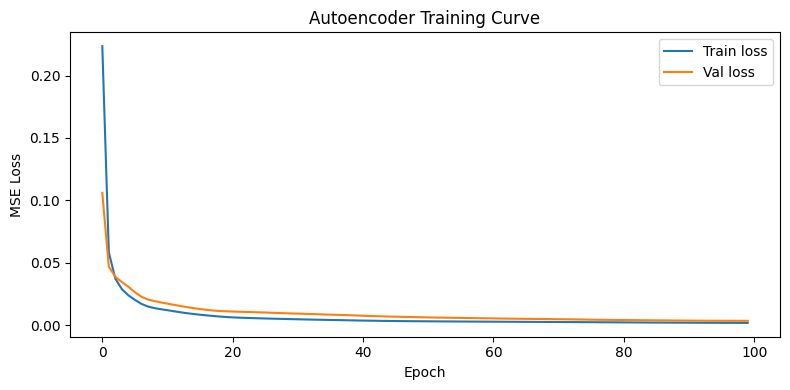

In [9]:
EPOCHS     = 100
BATCH_SIZE = 32
VAL_SPLIT  = 0.1

early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=10, restore_best_weights=True
)

history = autoencoder.fit(
    X_normal, X_normal,       
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=VAL_SPLIT,
    callbacks=[early_stop],
    verbose=1
)

plt.figure(figsize=(8, 4))
plt.plot(history.history['loss'],     label='Train loss')
plt.plot(history.history['val_loss'], label='Val loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Autoencoder Training Curve')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
def reconstruction_error(model, X):
    """Return per-sample MSE between input and reconstruction."""
    X_reconstructed = model.predict(X, verbose=0)
    return np.mean((X - X_reconstructed) ** 2, axis=1)

ae_scores_issue  = reconstruction_error(autoencoder, X_issue)
ae_scores_normal = reconstruction_error(autoencoder, X_normal)

print(f"Reconstruction error Normal training data: mean={ae_scores_normal.mean():.5f}, std={ae_scores_normal.std():.5f}")
print(f"Reconstruction error Issue run (all): mean={ae_scores_issue.mean():.5f}, std={ae_scores_issue.std():.5f}")
print(f"Reconstruction error Issue run (normal): mean={ae_scores_issue[y_issue==0].mean():.5f}")
print(f"Reconstruction error Issue run (anomalies): mean={ae_scores_issue[y_issue==1].mean():.5f}")

Reconstruction error — Normal training data: mean=0.00200, std=0.00228
Reconstruction error — Issue run (all): mean=0.13450, std=0.01032
Reconstruction error — Issue run (normal): mean=0.13519
Reconstruction error — Issue run (anomalies): mean=0.12414


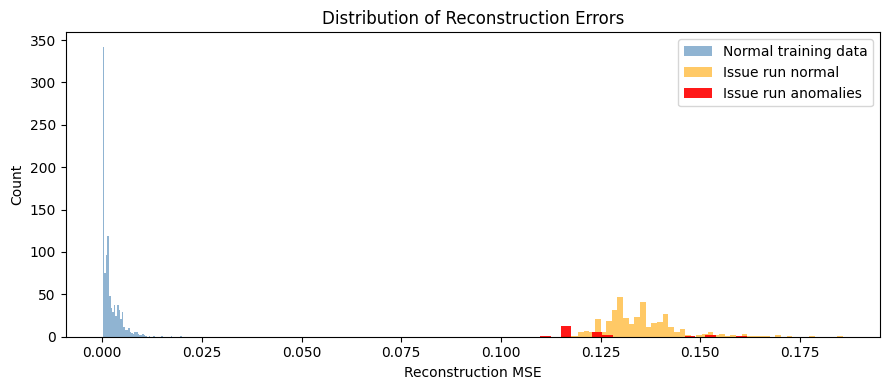

Autoencoder (MSE)               AUC-ROC: 0.1733  |  Best-threshold predictions:
[[344  31]
 [ 21   4]]


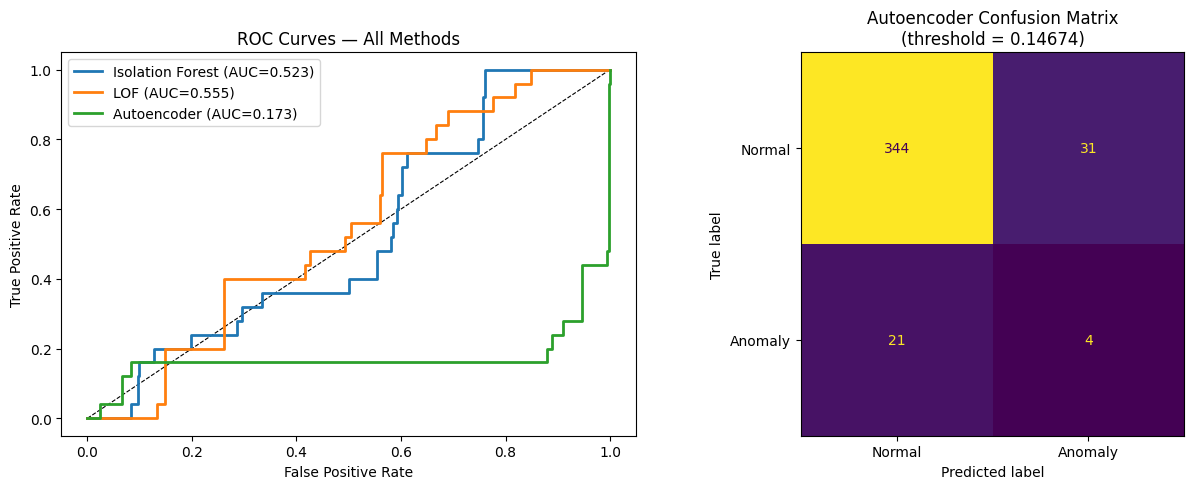

In [14]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(ae_scores_normal, bins=50, alpha=0.6, label='Normal training data', color='steelblue')
ax.hist(ae_scores_issue[y_issue==0], bins=50, alpha=0.6, label='Issue run normal', color='orange')
ax.hist(ae_scores_issue[y_issue==1], bins=20, alpha=0.9, label='Issue run anomalies', color='red')
ax.set_xlabel('Reconstruction MSE')
ax.set_ylabel('Count')
ax.set_title('Distribution of Reconstruction Errors')
ax.legend()
plt.tight_layout()
plt.show()

auc_ae, fpr_ae, tpr_ae = evaluate_detector('Autoencoder (MSE)', ae_scores_issue, y_issue)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot([0,1],[0,1],'k--', lw=0.8)
for name, fpr, tpr, auc in [
    ('Isolation Forest',*roc_curve(y_issue, iso_scores)[:2], roc_auc_score(y_issue, iso_scores)),
    ('LOF',*roc_curve(y_issue, lof_scores)[:2], roc_auc_score(y_issue, lof_scores)),
    ('Autoencoder', fpr_ae, tpr_ae, auc_ae),
]:
    axes[0].plot(fpr, tpr, lw=2, label=f'{name} (AUC={auc:.3f})')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curves — All Methods')
axes[0].legend()

fpr_ae_full, tpr_ae_full, thresh_ae = roc_curve(y_issue, ae_scores_issue)
best_thresh_ae = thresh_ae[np.argmax(tpr_ae_full - fpr_ae_full)]
preds_ae = (ae_scores_issue >= best_thresh_ae).astype(int)
cm_ae = confusion_matrix(y_issue, preds_ae)
disp = ConfusionMatrixDisplay(cm_ae, display_labels=['Normal', 'Anomaly'])
disp.plot(ax=axes[1], colorbar=False)
axes[1].set_title(f'Autoencoder Confusion Matrix\n(threshold = {best_thresh_ae:.5f})')

plt.tight_layout()
plt.show()

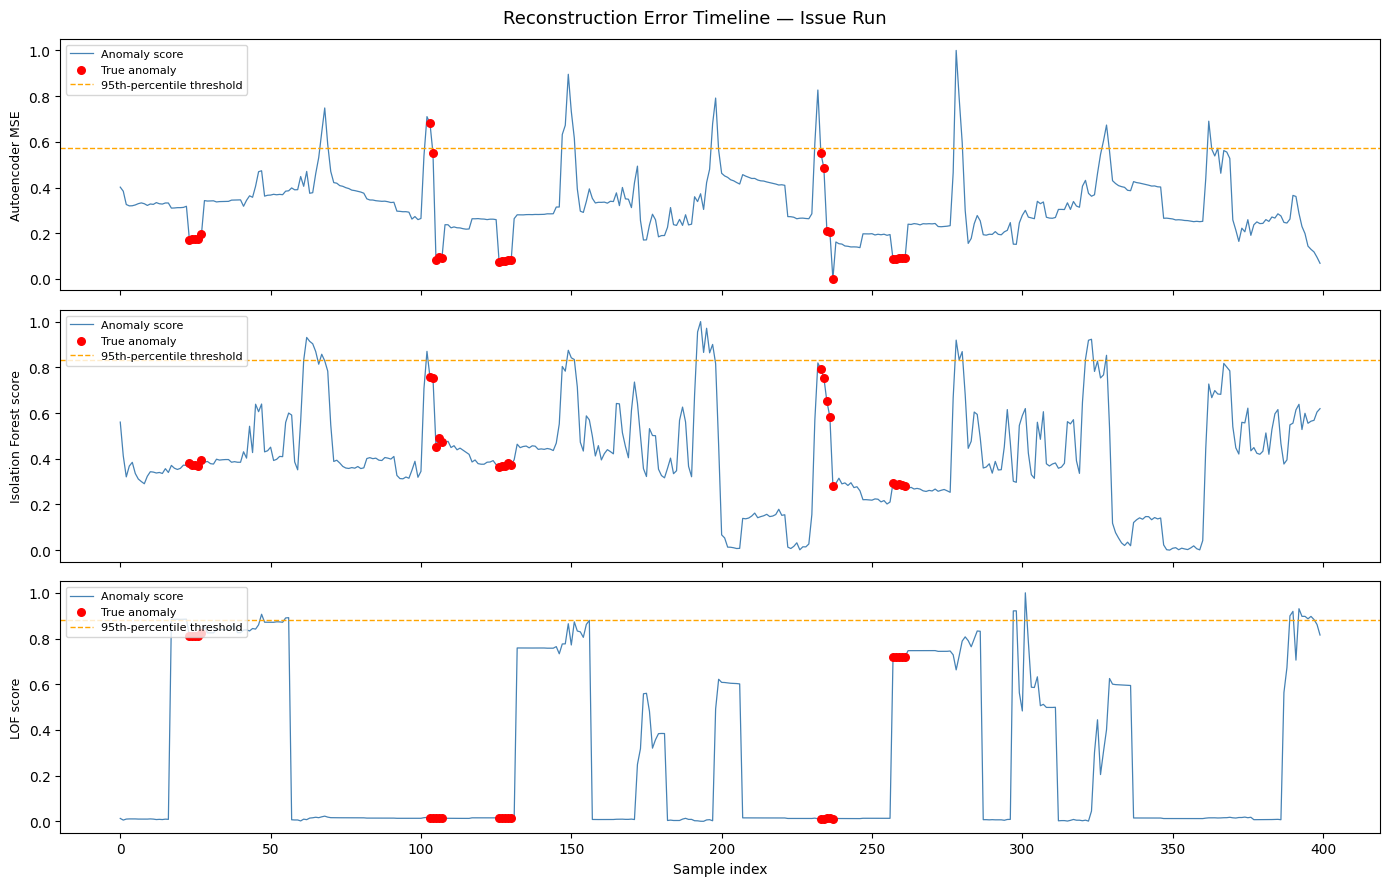

In [12]:
t = np.arange(len(ae_scores_issue))

fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)
fig.suptitle('Reconstruction Error Timeline — Issue Run', fontsize=13)

for ax, (name, scores) in zip(axes, [
    ('Autoencoder MSE', ae_scores_issue),
    ('Isolation Forest score', iso_scores),
    ('LOF score', lof_scores),
]):
    s_norm = (scores - scores.min()) / (scores.max() - scores.min() + 1e-12)
    ax.plot(t, s_norm, lw=0.9, color='steelblue', label='Anomaly score')
    ax.scatter(t[y_issue==1], s_norm[y_issue==1], color='red', s=30, zorder=5, label='True anomaly')
    ax.axhline(np.percentile(s_norm, 95), color='orange', lw=1, ls='--', label='95th-percentile threshold')
    ax.set_ylabel(name, fontsize=9)
    ax.legend(fontsize=8, loc='upper left')

axes[-1].set_xlabel('Sample index')
plt.tight_layout()
plt.show()